In [1]:
import pandas as pd

def custom_read(path):
    df = pd.read_csv(path)
    original_mAP = df["score"].iloc[0]
    map_nc_std = df["rnd:std"].to_list()
    df = df.drop(["score", "rnd:min", "rnd:max", "rnd:mean", "rnd:std"], axis=1)
    df = df.rename(columns={'Unnamed: 0': 'confidence threshold'})
    return df, original_mAP, map_nc_std

all_df = {
    "dota": {
        "S2ANet": custom_read("./work_dirs/s2anet-le135_r50_fpn_1x_dota-512/results_val_score_threshold.csv"), 
        "RetinaNet": custom_read("./work_dirs/rotated-retinanet-rbox-le90_r50_fpn_1x_dota-512/results_val_score_threshold.csv"),
        "FCOS": custom_read("./work_dirs/rotated-fcos-le90_r50_fpn_1x_dota-512/results_val_score_threshold.csv"),
        "Faster RCNN": custom_read("./work_dirs/rotated-faster-rcnn-le90_r50_fpn_1x_dota-512/results_val_score_threshold.csv"),
        "ATSS": custom_read("./work_dirs/rotated-atss-le90_r50_fpn_1x_dota-512/results_val_score_threshold.csv"),
        "ROI Trans.": custom_read("./work_dirs/roi-trans-le90_r50_fpn_1x_dota-512/results_val_score_threshold.csv"),
        "GWD": custom_read("./work_dirs/gwd_rotated-retinanet-rbox-le90_r50_fpn_gwd_1x_dota-512/results_val_score_threshold.csv"),
        "R3Det": custom_read("./work_dirs/r3det-oc_r50_fpn_1x_dota-512/results_val_score_threshold.csv"),
    }, 
}

all_df["dota"]["RetinaNet"][0]

,confidence threshold,1,rnd:42,rnd:666,rnd:6666,rnd:66666,rnd:666666,rnd:2024,rnd:9968,rnd:0,rnd:1,rnd:123
0,0.00,0.095145,0.116296,0.076850,0.084323,0.073752,0.134215,0.092914,0.098485,0.092939,0.092179,0.078265
1,0.05,0.095145,0.116296,0.076850,0.084323,0.073752,0.134215,0.092914,0.098485,0.092939,0.092179,0.078265
2,0.10,0.213836,0.235452,0.212635,0.208776,0.192169,0.247590,0.218311,0.229689,0.215471,0.223473,0.204307
3,0.15,0.323112,0.332326,0.329964,0.320215,0.304529,0.340014,0.325706,0.327751,0.322189,0.334317,0.318809
4,0.20,0.416801,0.414974,0.418518,0.406943,0.403525,0.421232,0.412963,0.417448,0.417419,0.416310,0.410071
5,0.25,0.481934,0.476854,0.482626,0.471645,0.468757,0.490194,0.471871,0.476619,0.474045,0.473189,0.474542
6,0.30,0.525617,0.522051,0.528473,0.525019,0.518077,0.527421,0.527708,0.525550,0.526432,0.520602,0.527565
7,0.35,0.558297,0.550651,0.556347,0.553448,0.550844,0.554267,0.553025,0.553072,0.555404,0.556234,0.557148
8,0.40,0.564868,0.555829,0.561539,0.560336,0.559843,0.560424,0.557345,0.559659,0.559469,0.563256,0.561039
9,0.45,0.560146,0.556129,0.557095,0.555126,0.554662,0.555506,0.554856,0.553848,0.555397,0.560621,0.558879


In [2]:
def convert_to_long_format(df, model_name):
    df_long = pd.melt(
        df,
        id_vars=['confidence threshold'],
        value_vars=['1', 'rnd:42', 'rnd:666', 'rnd:6666', 'rnd:66666', 'rnd:666666', 'rnd:2024', 'rnd:9968', 'rnd:0', 'rnd:1', 'rnd:123'],
        var_name='setting',
        value_name='mAP_nc'
    )
    df_long['Model'] = model_name
    return df_long

df_long = []
df_long.append(convert_to_long_format(all_df["dota"]["S2ANet"][0], "S2ANet"))
df_long.append(convert_to_long_format(all_df["dota"]["RetinaNet"][0], "RetinaNet"))
df_long.append(convert_to_long_format(all_df["dota"]["FCOS"][0], "FCOS"))
df_long.append(convert_to_long_format(all_df["dota"]["Faster RCNN"][0], "Faster RCNN"))
df_long.append(convert_to_long_format(all_df["dota"]["ATSS"][0], "ATSS"))
df_long.append(convert_to_long_format(all_df["dota"]["ROI Trans."][0], "ROI Trans."))
df_long.append(convert_to_long_format(all_df["dota"]["GWD"][0], "GWD"))
df_long.append(convert_to_long_format(all_df["dota"]["R3Det"][0], "R3Det"))

df_long = pd.concat(df_long, ignore_index=True)
df_long["mAP_nc"] = df_long["mAP_nc"] * 100
df_long

,confidence threshold,setting,mAP_nc,Model
0,0.00,1,9.818225,S2ANet
1,0.05,1,9.818225,S2ANet
2,0.10,1,23.578694,S2ANet
3,0.15,1,36.769870,S2ANet
4,0.20,1,44.986016,S2ANet
...,...,...,...,...
1755,0.75,rnd:123,31.691468,R3Det
1756,0.80,rnd:123,25.854474,R3Det
1757,0.85,rnd:123,21.160015,R3Det
1758,0.90,rnd:123,14.537725,R3Det


Times New Roman


findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


{'S2ANet': 76.5213131904602}


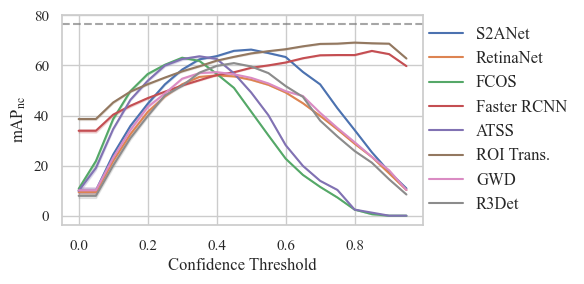

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import font_manager

sns.set_theme(style="whitegrid")

font_manager.fontManager.addfont("./times.ttf")
times_new_roman = font_manager.FontProperties(fname="./times.ttf")
print(times_new_roman.get_name())
rcParams['font.family'] = times_new_roman.get_name()
rcParams['mathtext.fontset'] = 'custom'
rcParams['mathtext.rm'] = times_new_roman.get_name()
rcParams['mathtext.it'] = times_new_roman.get_name()
rcParams['mathtext.bf'] = times_new_roman.get_name()
rcParams['font.weight'] = 'bold'
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.titleweight'] = 'bold'

plt.figure(figsize=(6, 3))

sns.lineplot(
    x="confidence threshold", 
    y="mAP_nc", 
    hue="Model", 
    # style="Dataset", 
    data=df_long
)

original_mAP = {
    "S2ANet": all_df["dota"]["S2ANet"][1] * 100,
    "S2ANet": all_df["dota"]["RetinaNet"][1] * 100,
    "S2ANet": all_df["dota"]["FCOS"][1] * 100,
    "S2ANet": all_df["dota"]["Faster RCNN"][1] * 100,
    "S2ANet": all_df["dota"]["ATSS"][1] * 100,
    "S2ANet": all_df["dota"]["ROI Trans."][1] * 100,
    "S2ANet": all_df["dota"]["GWD"][1] * 100,
    "S2ANet": all_df["dota"]["R3Det"][1] * 100,
}
print(original_mAP)
for label, y in original_mAP.items():
    plt.axhline(y=y, linestyle="--", color="gray", alpha=0.7)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    borderaxespad=0,
    frameon=False, 
    prop=font_manager.FontProperties(fname="./times.ttf", weight='bold')
)

plt.xlabel("Confidence Threshold", fontweight='bold', fontproperties=times_new_roman)
plt.ylabel(r"$mAP_{nc}$", fontweight='bold', fontproperties=times_new_roman)
plt.tight_layout()

plt.savefig("score_impact.svg", bbox_inches='tight')  # 保存为 SVG 格式
plt.show()

In [5]:
# import numpy as np
# all_std = {
#     "RetinaNet@DOTA": (np.array(all_df["dota"]["Rotated RetinaNet"][2]) * 100).tolist(),  # 不然重叠了难看
#     "FCOS@DOTA": (np.array(all_df["dota"]["Rotated FCOS"][2]) * 100).tolist(),
#     "RetinaNet@DIOR": (np.array(all_df["dior"]["Rotated RetinaNet"][2]) * 100).tolist(),
#     "FCOS@DIOR": (np.array(all_df["dior"]["Rotated FCOS"][2]) * 100).tolist()
# }
# for k, v in all_std.items():
#     print(k, "\n", v)

RetinaNet@DOTA 
 [1.8026207166771402, 1.8026207166771402, 1.31986902259358, 1.21732545023143, 1.26535384932444, 0.9691423465705199, 0.6607766042088501, 0.65457125956423, 0.60396554547793, 0.47397303299032006, 0.26696476303125, 0.24387671589308, 0.12515766921603, 0.14125963886034001, 0.06952950186539, 0.04295178294085, 0.037193166494090005, 0.01740951896208, 0.0111379604751, 0.00139004257595092]
FCOS@DOTA 
 [1.89466819984269, 1.82737044080694, 1.190606104786, 0.86107087600321, 0.67941646416452, 0.45725777185784006, 0.33936273707369, 0.1518650458065, 0.18605395125509, 0.11924902901249, 0.06774019939485, 0.04368608820968, 0.006834218618852177, 0.005959739419734005, 0.0012010404978872512, 0.0, 0.0, 0.0, 0.0, 0.0]
RetinaNet@DIOR 
 [3.43265888652191, 3.43265888652191, 4.032990260850481, 3.1756319271254303, 2.25625760554932, 1.50777358970838, 1.1517360325203, 0.66612303689676, 0.48360658243653, 0.42074127419784, 0.24132414645284, 0.16559478260541, 0.09677389923214, 0.10742970954035001, 0.1430